# Quem Recebe Mais Atenção? Análise de Engajamento: Trump vs AOC
## Entendendo Como as Audiências Respondem a Postagens Políticas

---

### Por Que o Engajamento Importa?

No primeiro notebook, exploramos *o que* Trump e AOC postam e *quando* postam. Agora voltamos nossa atenção para uma questão diferente: **como a audiência responde?**

Na comunicação política tradicional -- jornais, rádio, televisão -- era muito difícil medir a resposta da audiência em tempo real. Um político podia fazer um discurso, mas tinha que esperar por pesquisas, cartas ou resultados eleitorais para saber se a mensagem havia funcionado. As redes sociais mudam isso completamente. Cada tweet gera feedback imediato e mensurável: curtidas, repostagens, respostas, salvos e visualizações.

É por isso que a análise de engajamento é tão valiosa para estudar a comunicação política contemporânea. Ela nos dá uma janela para **como as audiências recebem e amplificam mensagens políticas** -- algo que historiadores de períodos anteriores só podem sonhar em ter.

Neste notebook, exploraremos:

1. **Engajamento geral** -- Quem recebe mais atenção total?
2. **Taxa de engajamento** -- Quem é melhor em transformar espectadores em participantes?
3. **Viralidade** -- Quais tweets se espalham mais, e por quê?
4. **Efeitos do formato de conteúdo** -- Fotos ou vídeos recebem mais atenção?
5. **Efeitos do horário** -- Quando é o melhor horário para postar para máxima resposta?
6. **Salvos** -- Quais tweets as pessoas guardam para depois?

---

### Termos-Chave Para Este Notebook

- **Engajamento**: Qualquer ação que um espectador realiza em um tweet -- curtir, repostar, responder, citar ou salvar.
- **Taxa de engajamento = total de interações / visualizações (qual porcentagem das pessoas que viram o tweet realmente interagiu com ele)**: Esta é a métrica mais importante deste notebook. Um tweet visto por 10 milhões de pessoas mas curtido por apenas 1.000 tem uma taxa de engajamento baixa. Um tweet visto por 50.000 pessoas mas curtido por 5.000 tem uma taxa muito maior.
- **Índice de viralidade**: Uma medida de quanto um tweet foi compartilhado (repostado) em relação a quantas pessoas o viram. Tweets virais são aqueles que se espalham rapidamente além da audiência original.
- **Taxa de salvos**: Com que frequência as pessoas salvam um tweet para depois. Esta é uma forma de engajamento mais silenciosa e deliberada do que uma rápida "curtida".
- **Média**: Some todos os valores e divida pela quantidade.
- **Mediana (valor do meio)**: Menos afetada por valores extremos do que a média.
- **Distribuição (como os dados se espalham pelos diferentes valores)**: Pense nisso como um gráfico de barras mostrando onde a maioria dos valores cai -- estão agrupados juntos ou espalhados?

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import load_tweets
from utils.plot_helpers import (
    setup_style, get_colors, get_user_label,
    comparative_bar, comparative_boxplot, comparative_hist,
    format_large_numbers, add_summary_stats, set_language
)
from config import FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE, RANDOM_SEED

setup_style()
set_language('pt-br')
colors = get_colors()
np.random.seed(RANDOM_SEED)

print('Configuração concluída.')

Configuração concluída.


In [2]:
df = load_tweets()

# Verificação rápida
print(f"Formato: {df.shape}")
print(f"Usuários: {df['user'].value_counts().to_dict()}")
print(f"Intervalo de datas: {df['created_at'].min()} até {df['created_at'].max()}")

Loaded 200 tweets from processed/
Formato: (200, 42)
Usuários: {'aoc': 100, 'trump': 100}
Intervalo de datas: 2025-04-01 20:53:05+00:00 até 2026-02-26 15:32:57+00:00


## 1. O Panorama Geral: Quem Recebe Mais Atenção Total?

Vamos começar com a pergunta mais simples: em todos os 100 tweets que coletamos para cada político, quem recebeu mais curtidas, repostagens, respostas, citações, salvos e visualizações no total?

Tenha em mente que **números totais** podem ser enganosos. Um político com um público muito maior naturalmente receberá mais engajamento total. É por isso que também analisaremos as *taxas* de engajamento (porcentagens) mais adiante. Mas os totais nos dão um ponto de partida útil para entender a escala absoluta de atenção da audiência.

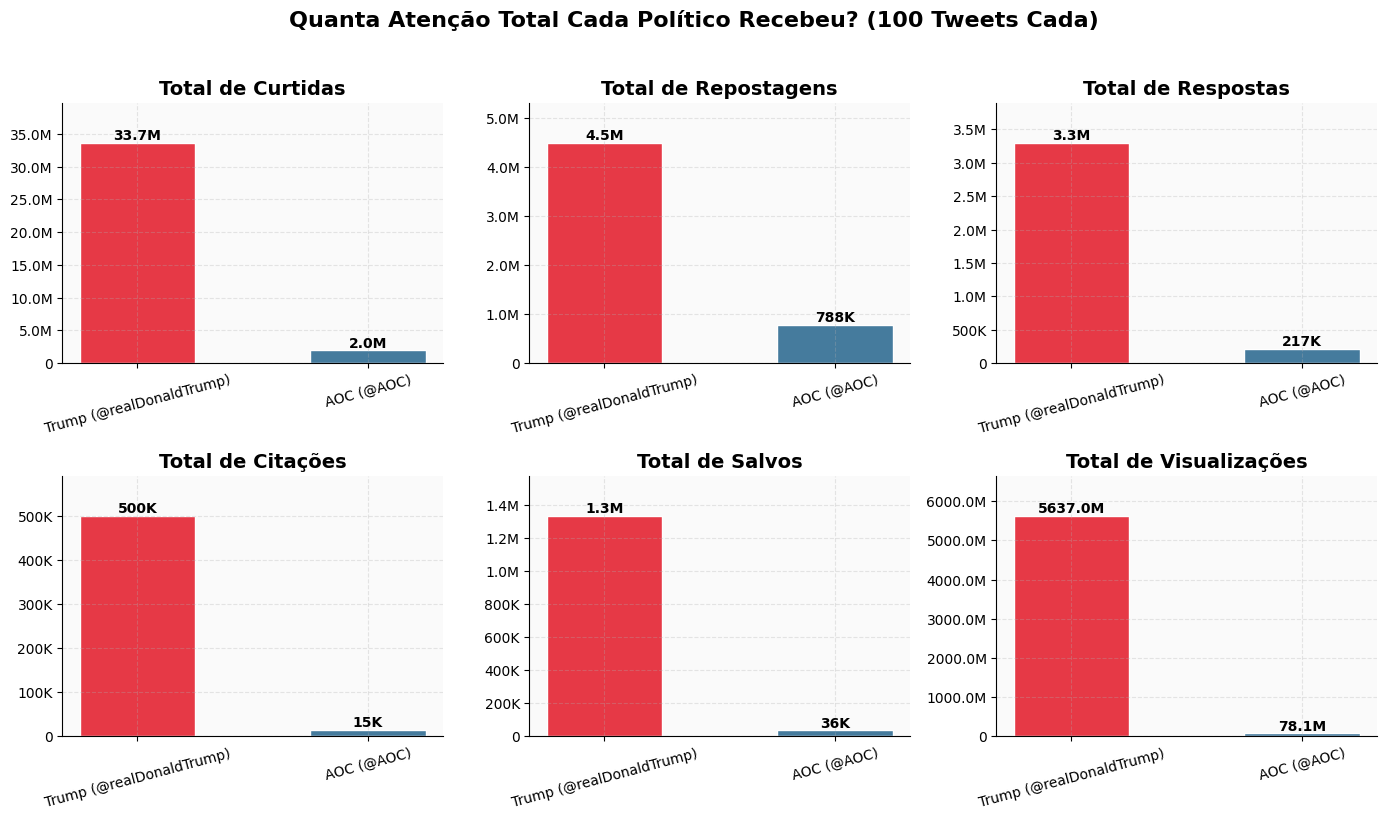

In [3]:
# --- Engajamento Total: Quanta Atenção Cada Político Recebeu? ---

engagement_metrics = [
    ('favorite_count', 'Curtidas'),
    ('retweet_count', 'Repostagens'),
    ('reply_count', 'Respostas'),
    ('quote_count', 'Citações'),
    ('bookmark_count', 'Salvos'),
    ('view_count', 'Visualizações'),
]

fig, axes = plt.subplots(2, 3, figsize=FIGURE_SIZE_LARGE)
axes = axes.flatten()

for idx, (metric, label) in enumerate(engagement_metrics):
    ax = axes[idx]
    users = ['trump', 'aoc']
    totals = [df[df['user'] == u][metric].sum() for u in users]
    user_labels = [get_user_label(u) for u in users]
    
    bars = ax.bar(user_labels, totals,
                  color=[colors[u] for u in users],
                  width=0.5, edgecolor='white')
    
    # Adicionar rótulos de valor nas barras
    for bar, val in zip(bars, totals):
        if val >= 1_000_000:
            display_val = f"{val/1_000_000:.1f}M"
        elif val >= 1_000:
            display_val = f"{val/1_000:.0f}K"
        else:
            display_val = f"{val:,.0f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                display_val, ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    
    ax.set_title(f'Total de {label}', fontweight='bold')
    ax.set_ylim(0, max(totals) * 1.18 if max(totals) > 0 else 1)
    format_large_numbers(ax)
    
    # Rotacionar rótulos do eixo x para legibilidade
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Quanta Atenção Total Cada Político Recebeu? (100 Tweets Cada)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### O que isso nos diz?

Esses seis gráficos mostram o número total de cada tipo de interação entre todos os 100 tweets de cada político. Os números rotulados no topo de cada barra facilitam a comparação.

Observe qual político domina em **visualizações** (alcance bruto) versus **respostas** (conversa ativa). Um político com muitas visualizações mas relativamente menos respostas tem uma audiência que principalmente assiste passivamente. Um com uma alta contagem de respostas em relação às visualizações tem uma audiência que ativamente responde. Ambos os padrões nos dizem algo sobre o relacionamento entre o político e seus seguidores.

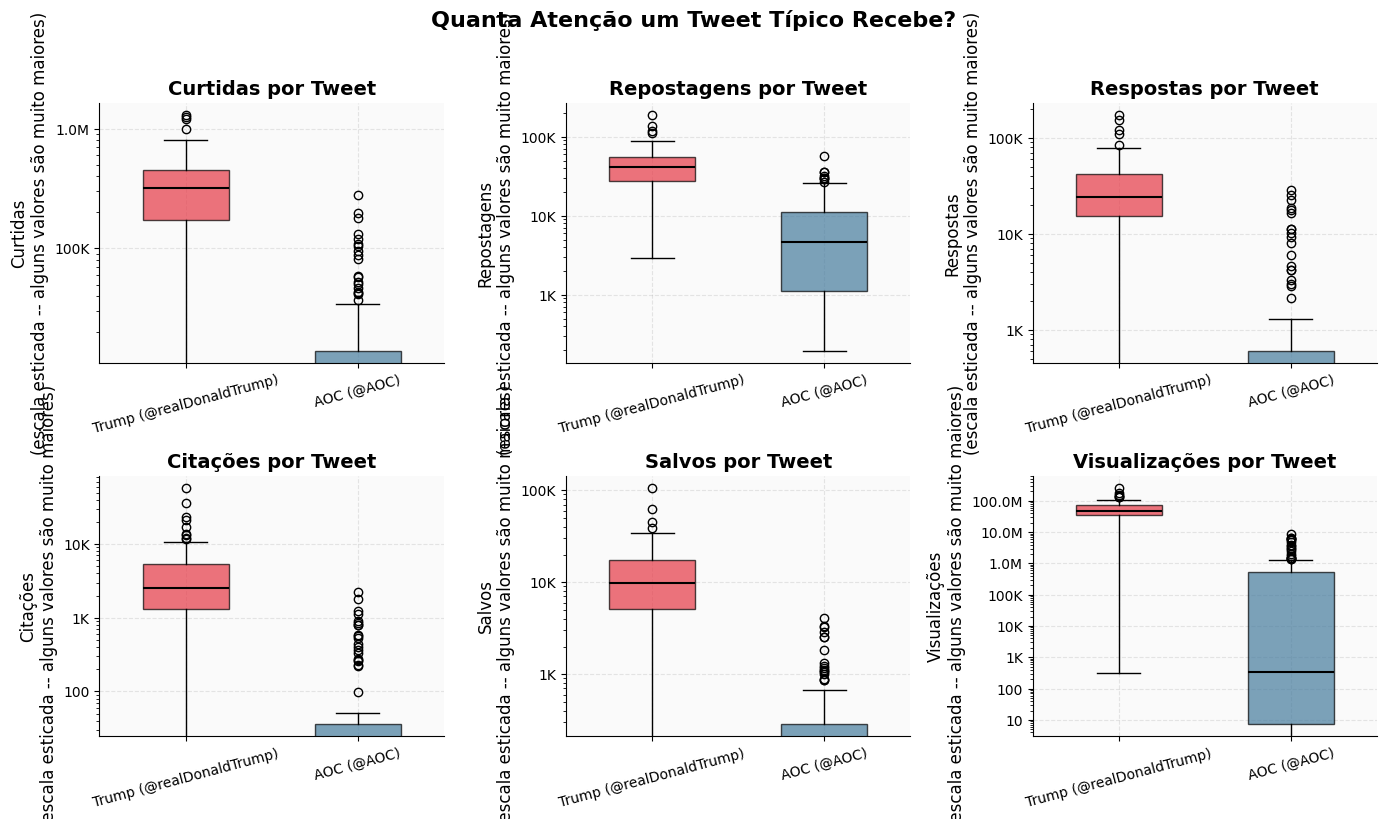

In [4]:
# --- Quanta Atenção um Tweet Típico Recebe? (Box Plots) ---

fig, axes = plt.subplots(2, 3, figsize=FIGURE_SIZE_LARGE)
axes = axes.flatten()

for idx, (metric, label) in enumerate(engagement_metrics):
    ax = axes[idx]
    users = ['trump', 'aoc']
    data = [df[df['user'] == u][metric].dropna().values for u in users]
    user_labels = [get_user_label(u) for u in users]
    
    bp = ax.boxplot(data, labels=user_labels, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, user in zip(bp['boxes'], users):
        patch.set_facecolor(colors[user])
        patch.set_alpha(0.7)
    
    ax.set_title(f'{label} por Tweet', fontweight='bold')
    
    # Nota: esticamos a escala quando alguns números são muito maiores que outros
    max_val = max(d.max() for d in data if len(d) > 0)
    min_val = min(d[d > 0].min() if len(d[d > 0]) > 0 else 1 for d in data)
    if max_val > 0 and max_val / max(min_val, 1) > 100:
        ax.set_yscale('log')
        ax.set_ylabel(f'{label}\n(escala esticada -- alguns valores são muito maiores)')
    else:
        ax.set_ylabel(label)
    
    format_large_numbers(ax)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Quanta Atenção um Tweet Típico Recebe?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### O que isso nos diz?

Estes são chamados de **box plots** (diagramas de caixa). Veja como lê-los:

- A **caixa colorida** mostra a faixa onde os 50% centrais dos tweets se encontram (do percentil 25 ao percentil 75)
- A **linha preta dentro da caixa** é a mediana (valor do meio)
- As **linhas que se estendem da caixa** ("bigodes") mostram a faixa mais ampla de valores típicos
- Os **pontos além dos bigodes** são valores incomuns -- tweets que performaram muito melhor ou pior que o normal

Se a caixa de um político é muito mais alta que a do outro, seus tweets típicos recebem mais engajamento. Se um político tem muitos pontos acima dos bigodes, eles têm mais tweets que performaram excepcionalmente bem (hits virais).

*Nota: Em alguns gráficos, esticamos a escala vertical porque alguns números são muito maiores que outros. Isso facilita a visualização das diferenças, mas esteja ciente de que o espaçamento entre os números não é uniforme.*

## 2. Taxa de Engajamento: Quem Transforma Espectadores em Participantes?

Números brutos (total de curtidas, total de repostagens) podem ser enganosos porque dependem fortemente do tamanho da audiência. Um político com 90 milhões de seguidores naturalmente receberá mais curtidas que um com 10 milhões, mesmo se o conteúdo for menos envolvente.

É por isso que usamos a **taxa de engajamento = total de interações / visualizações (qual porcentagem das pessoas que viram o tweet realmente interagiu com ele)**. Isso nivela o campo de jogo perguntando: de todas as pessoas que *viram* um tweet, qual porcentagem realmente *fez algo* com ele?

Uma taxa de engajamento alta significa que o conteúdo ressoou fortemente com sua audiência. Uma taxa baixa significa que as pessoas viram mas na maioria passaram direto.

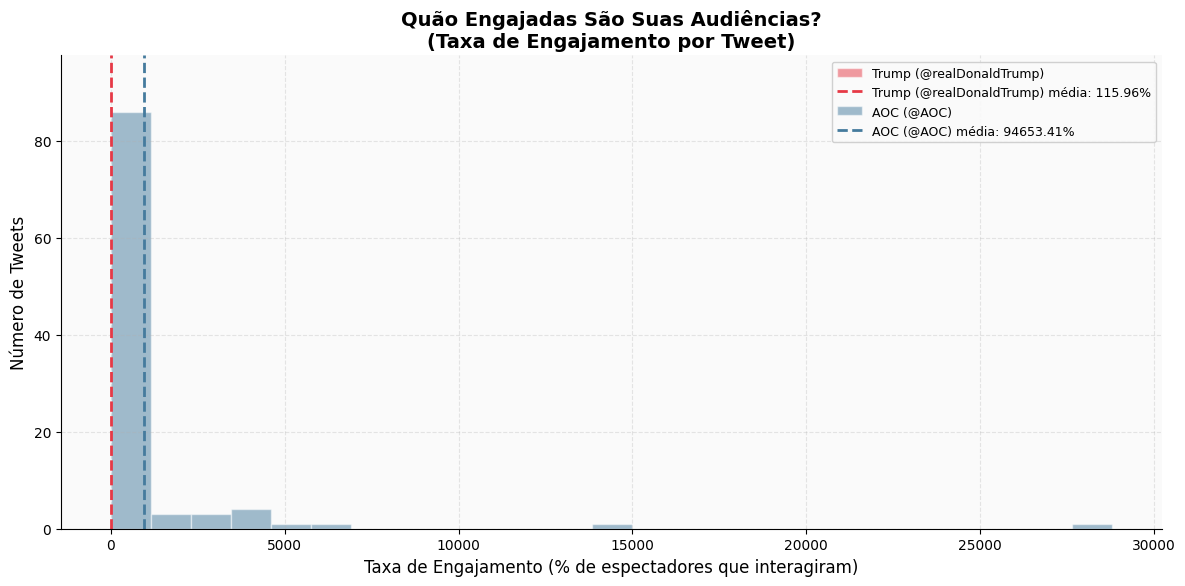

In [5]:
# --- Quão Engajadas São Suas Audiências? (Taxa de Engajamento por Tweet) ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['engagement_rate'].dropna()
    label = get_user_label(user)
    
    ax.hist(user_data, bins=25, alpha=0.5, label=label,
            color=colors[user], edgecolor='white')
    
    # Adicionar linha da média
    mean_val = user_data.mean()
    ax.axvline(mean_val, color=colors[user], linestyle='--', linewidth=2,
               label=f'{label} média: {mean_val:.2%}')

ax.set_title('Quão Engajadas São Suas Audiências?\n(Taxa de Engajamento por Tweet)', fontweight='bold', fontsize=14)
ax.set_xlabel('Taxa de Engajamento (% de espectadores que interagiram)')
ax.set_ylabel('Número de Tweets')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### O que isso nos diz?

Este gráfico mostra a distribuição das taxas de engajamento entre todos os tweets de cada político. As linhas tracejadas mostram a taxa média de engajamento.

Se as barras de um político estão deslocadas para a direita comparadas às do outro, significa que seus tweets consistentemente convertem uma porcentagem maior de espectadores em participantes ativos. Este é um forte indicador de lealdade da audiência e ressonância do conteúdo.

Pense desta forma: alcançar muitas pessoas é uma coisa (isso depende da contagem de seguidores e promoção algorítmica), mas fazer essas pessoas realmente *reagirem* é outra. A taxa de engajamento nos diz sobre a qualidade da conexão entre político e audiência.

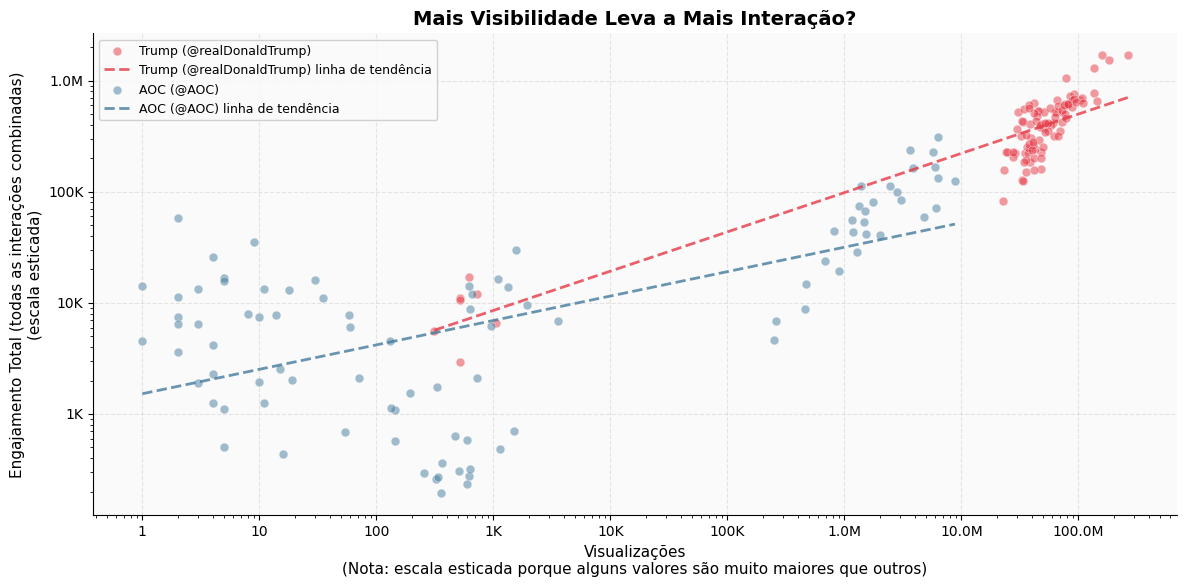

In [6]:
# --- Mais Visibilidade Leva a Mais Interação? (Visualizações vs Engajamento Total) ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    mask = (df['user'] == user) & (df['view_count'] > 0) & (df['total_engagement'] > 0)
    user_data = df[mask]
    label = get_user_label(user)
    
    ax.scatter(user_data['view_count'], user_data['total_engagement'],
               color=colors[user], alpha=0.5, s=40, label=label, edgecolors='white', linewidth=0.5)
    
    # Linha de tendência (mostra a direção geral da relação)
    log_x = np.log10(user_data['view_count'].values)
    log_y = np.log10(user_data['total_engagement'].values)
    coeffs = np.polyfit(log_x, log_y, 1)
    x_fit = np.linspace(log_x.min(), log_x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)
    ax.plot(10**x_fit, 10**y_fit, color=colors[user], linestyle='--',
            linewidth=2, alpha=0.8, label=f'{label} linha de tendência')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Visualizações\n(Nota: escala esticada porque alguns valores são muito maiores que outros)', fontsize=11)
ax.set_ylabel('Engajamento Total (todas as interações combinadas)\n(escala esticada)', fontsize=11)
ax.set_title('Mais Visibilidade Leva a Mais Interação?', fontweight='bold', fontsize=14)
ax.legend(fontsize=9)
format_large_numbers(ax, axis='x')
format_large_numbers(ax, axis='y')
plt.tight_layout()
plt.show()

### O que isso nos diz?

Cada ponto representa um tweet. Sua posição no eixo horizontal mostra quantas pessoas o viram (visualizações), e sua posição vertical mostra quantas interações recebeu. A linha de tendência tracejada mostra a relação geral entre visibilidade e engajamento.

Se os pontos de um político ficam consistentemente acima dos do outro, significa que eles recebem mais engajamento *para o mesmo número de visualizações* -- seu conteúdo é mais envolvente para sua audiência. Se os pontos estão muito dispersos, significa que o engajamento é imprevisível -- alguns tweets performam muito melhor que outros mesmo com visibilidade similar.

*Nota: Ambos os eixos estão esticados (isso às vezes é chamado de "escala logarítmica") porque alguns tweets recebem milhões de visualizações enquanto outros recebem milhares. Sem o esticamento, todos os pontos menores ficariam comprimidos em um canto e impossíveis de ler.*

In [7]:
# --- Comparação Detalhada de Taxa de Engajamento ---

rate_metrics = ['engagement_rate', 'like_rate', 'retweet_rate',
                'reply_rate', 'virality_score', 'save_rate']

stats_data = []
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user]
    row = {'Usuário': get_user_label(user)}
    for metric in rate_metrics:
        col_data = user_df[metric].dropna()
        nice_name = metric.replace('_', ' ').title()
        row[f'{nice_name} (Média)'] = col_data.mean()
        row[f'{nice_name} (Valor Central)'] = col_data.median()
        row[f'{nice_name} (Melhor Tweet)'] = col_data.max()
    stats_data.append(row)

stats_df = pd.DataFrame(stats_data).set_index('Usuário')

# Formatar valores
def fmt_val(x):
    if abs(x) < 1:
        return f"{x:.4f}"
    return f"{x:.2f}"

styled = stats_df.style.format(fmt_val).set_caption(
    'Detalhamento da Taxa de Engajamento: Média, Valor Central e Melhor Tweet'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}
])

display(styled)

,Engagement Rate (Média),Engagement Rate (Valor Central),Engagement Rate (Melhor Tweet),Like Rate (Média),Like Rate (Valor Central),Like Rate (Melhor Tweet),Retweet Rate (Média),Retweet Rate (Valor Central),Retweet Rate (Melhor Tweet),Reply Rate (Média),Reply Rate (Valor Central),Reply Rate (Melhor Tweet),Virality Score (Média),Virality Score (Valor Central),Virality Score (Melhor Tweet),Save Rate (Média),Save Rate (Valor Central),Save Rate (Melhor Tweet)
Usuário,,,,,,,,,,,,,,,,,,
Trump (@realDonaldTrump),1.16,0.0075,27.53,0.0057,0.0056,0.0146,1.15,0.0008,27.53,0.0005,0.0005,0.0017,1.15,0.0009,27.53,0.0002,0.0002,0.0008
AOC (@AOC),946.53,2.41,28802.50,0.0083,0.0000,0.0758,946.52,2.41,28802.50,0.0007,0.0000,0.0074,946.52,2.41,28802.50,0.0001,0.0000,0.0010


### O que isso nos diz?

Esta tabela detalha a taxa de engajamento em seus componentes:

- **Taxa de Engajamento**: Porcentagem geral de espectadores que interagiram
- **Taxa de Curtidas**: Porcentagem de espectadores que curtiram o tweet
- **Taxa de Repostagens**: Porcentagem de espectadores que compartilharam o tweet
- **Taxa de Respostas**: Porcentagem de espectadores que escreveram uma resposta
- **Índice de Viralidade**: Quanto o tweet foi compartilhado em relação às visualizações
- **Taxa de Salvos**: Porcentagem de espectadores que salvaram o tweet

Cada métrica conta uma história diferente. Altas taxas de curtidas significam aprovação passiva. Altas taxas de repostagens significam amplificação ativa. Altas taxas de respostas significam que o conteúdo provoca conversa. A coluna "Melhor Tweet" mostra o desempenho de pico -- o tweet mais engajador para cada métrica.

## 3. Viralização: Quais Tweets Se Espalharam Mais?

**Viralidade** -- o compartilhamento rápido e generalizado de conteúdo -- é um dos aspectos mais fascinantes da comunicação política digital. Um único tweet pode alcançar milhões de pessoas em horas, muito além dos próprios seguidores do político.

O que faz um tweet viralizar? É o tema? A redação? O momento? Vamos olhar os tweets mais virais de cada político e ver se conseguimos identificar padrões.

In [8]:
# --- Os 10 Tweets Mais Virais de Cada Político ---

for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user].nlargest(10, 'virality_score')
    
    display_df = user_df[['text', 'virality_score', 'favorite_count',
                          'retweet_count', 'view_count']].copy()
    display_df['text'] = display_df['text'].str[:80] + '...'
    display_df = display_df.reset_index(drop=True)
    display_df.index = display_df.index + 1  # ranking baseado em 1
    display_df.index.name = 'Posição'
    
    # Formatar colunas numéricas
    display_df['virality_score'] = display_df['virality_score'].apply(lambda x: f"{x:.4f}")
    display_df['favorite_count'] = display_df['favorite_count'].apply(lambda x: f"{x:,.0f}")
    display_df['retweet_count'] = display_df['retweet_count'].apply(lambda x: f"{x:,.0f}")
    display_df['view_count'] = display_df['view_count'].apply(lambda x: f"{x:,.0f}")
    
    display_df.columns = ['Texto do Tweet (primeiros 80 caracteres)', 'Índice de Viralidade', 'Curtidas', 'Repostagens', 'Visualizações']
    
    print(f"\n{'='*80}")
    print(f"Top 10 Tweets Mais Virais -- {get_user_label(user)}")
    print(f"{'='*80}")
    display(display_df)


Top 10 Tweets Mais Virais -- Trump (@realDonaldTrump)


,Texto do Tweet (primeiros 80 caracteres),Índice de Viralidade,Curtidas,Repostagens,Visualizações
Posição,,,,,
1,RT @kaitrump: I had an amazing time filming wi...,27.5297,0,"17,151",623
2,"RT @DanScavino: On behalf of Erin and me, than...",21.0364,0,"10,981",522
3,"RT @MELANIATRUMP: MELANIA, the film.\n#1 Highe...",20.6680,0,"10,706",518
4,"RT @FoxNews: RECORD BREAKER: “Melania,” a docu...",17.6773,0,"5,533",313
5,RT @johnrich: A conversation about online chil...,16.4822,0,"12,032",730
6,RT @nypost: Democratic Rep. Jasmine Crockett a...,6.2220,0,"6,558","1,054"
7,RT @THR: Box Office: ‘Melania’ Heads for $8 Mi...,5.6130,0,"2,930",522
8,https://t.co/JzQYLShOCt...,0.0022,"460,110","80,916","41,656,800"
9,https://t.co/08KV4EtQDZ...,0.0019,"390,427","55,943","30,443,479"



Top 10 Tweets Mais Virais -- AOC (@AOC)


,Texto do Tweet (primeiros 80 caracteres),Índice de Viralidade,Curtidas,Repostagens,Visualizações
Posição,,,,,
1,RT @PopBase: Bad Bunny closed out his #SuperBo...,28802.5000,0,"57,605",2
2,RT @brianstelter: A statement from the family ...,14259.0000,0,"14,259",1
3,RT @HillaryClinton: So let’s stop the games. \...,6513.2500,0,"26,053",4
4,"RT @atrupar: AOC: ""How rich is it that she is ...",5689.0000,0,"11,378",2
5,RT @WSJ: Exclusive: A U.S. official has allege...,4520.0000,0,"4,520",1
6,RT @IlhanMN: I’m ok. I’m a survivor so this sm...,4434.0000,0,"13,302",3
7,RT @jaketapper: DOJ has since killed this link...,3942.7778,0,"35,485",9
8,RT @RepThomasMassie: 🧵1) This is significant b...,3766.5000,0,"7,533",2
9,RT @RepRaskin: The DOJ is giving Members of Co...,3341.2000,0,"16,706",5


### O que isso nos diz?

Leia o texto real dos tweets mais virais. Quais temas aparecem? São sobre políticas públicas, ataques pessoais, comentários culturais ou notícias de última hora? Conteúdo viral frequentemente acessa emoções fortes -- indignação, humor, solidariedade ou surpresa.

Ao ler esses tweets, pense no que um historiador daqui a 50 anos aprenderia sobre a cultura política americana a partir dessas mensagens mais compartilhadas. Quais questões importam para a audiência de cada político? Qual tom ressoa mais?

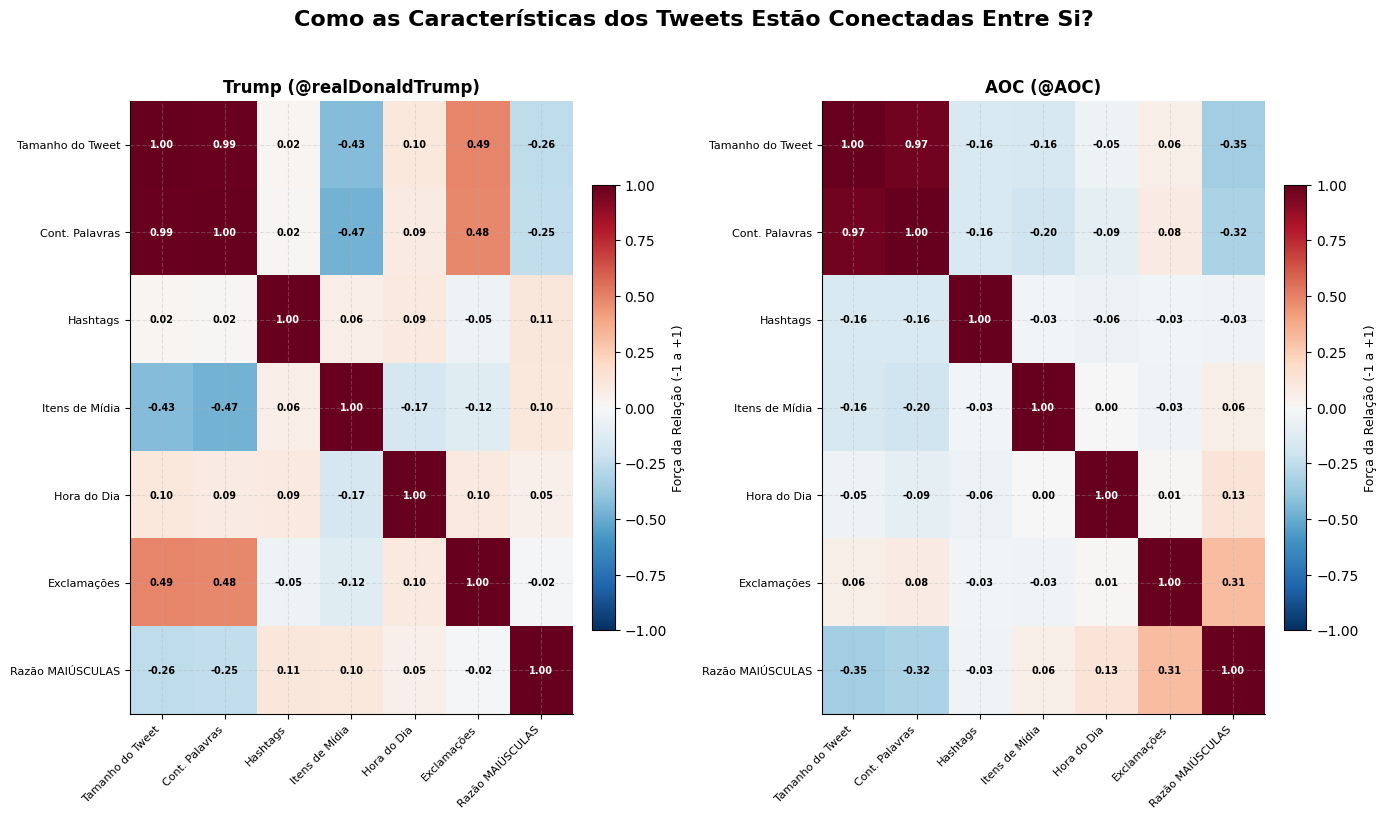

In [9]:
# --- Quais Características dos Tweets Estão Conectadas a Maior Engajamento? ---

correlation_features = ['text_length', 'word_count', 'hashtag_count',
                        'media_count', 'hour', 'exclamation_count', 'caps_ratio']

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_df = df[df['user'] == user]
    
    # Quão fortemente cada característica está conectada às outras?
    corr_data = user_df[['engagement_rate'] + correlation_features].corr()
    
    corr_matrix = corr_data.loc[correlation_features, correlation_features]
    
    # Criar mapa de calor
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    
    # Definir rótulos com nomes em português
    feature_labels = {
        'text_length': 'Tamanho do Tweet',
        'word_count': 'Cont. Palavras',
        'hashtag_count': 'Hashtags',
        'media_count': 'Itens de Mídia',
        'hour': 'Hora do Dia',
        'exclamation_count': 'Exclamações',
        'caps_ratio': 'Razão MAIÚSCULAS'
    }
    labels = [feature_labels.get(f, f) for f in correlation_features]
    ax.set_xticks(range(len(correlation_features)))
    ax.set_yticks(range(len(correlation_features)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    
    # Adicionar valores como texto
    for i in range(len(correlation_features)):
        for j in range(len(correlation_features)):
            val = corr_matrix.values[i, j]
            text_color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=7, color=text_color, fontweight='bold')
    
    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=12)
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Força da Relação (-1 a +1)', fontsize=9)

fig.suptitle('Como as Características dos Tweets Estão Conectadas Entre Si?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### O que isso nos diz?

Este gráfico é chamado de **mapa de calor**. Ele mostra quão fortemente diferentes características dos tweets estão conectadas entre si. Veja como lê-lo:

- **Quadrados vermelhos** (valores próximos de +1,00) significam que duas características tendem a andar juntas. Por exemplo, se Tamanho do Tweet e Contagem de Palavras estão em vermelho vivo, significa que tweets mais longos naturalmente têm mais palavras (sem surpresa).
- **Quadrados azuis** (valores próximos de -1,00) significam que duas características se movem em direções opostas. Por exemplo, se Hashtags e Tamanho do Tweet estão em azul, pode significar que tweets mais curtos usam mais hashtags.
- **Quadrados brancos/claros** (valores próximos de 0,00) significam nenhuma conexão clara entre as duas características.

Procure padrões interessantes: tweets com mais exclamações ou MAIÚSCULAS tendem a estar conectados com outras características? Existem diferenças entre Trump e AOC em como essas características se relacionam? Essas conexões nos ajudam a entender o estilo de escrita de cada político em um nível estrutural.

## 4. Fotos ou Vídeos Recebem Mais Atenção?

Importa se um tweet inclui uma foto, um vídeo ou apenas texto? Esta seção examina como diferentes formatos de conteúdo performam para cada político.

Na era das redes sociais visuais, a sabedoria convencional diz que imagens e vídeos atraem mais atenção que texto puro. Mas isso é verdade para conteúdo político? Vamos descobrir.

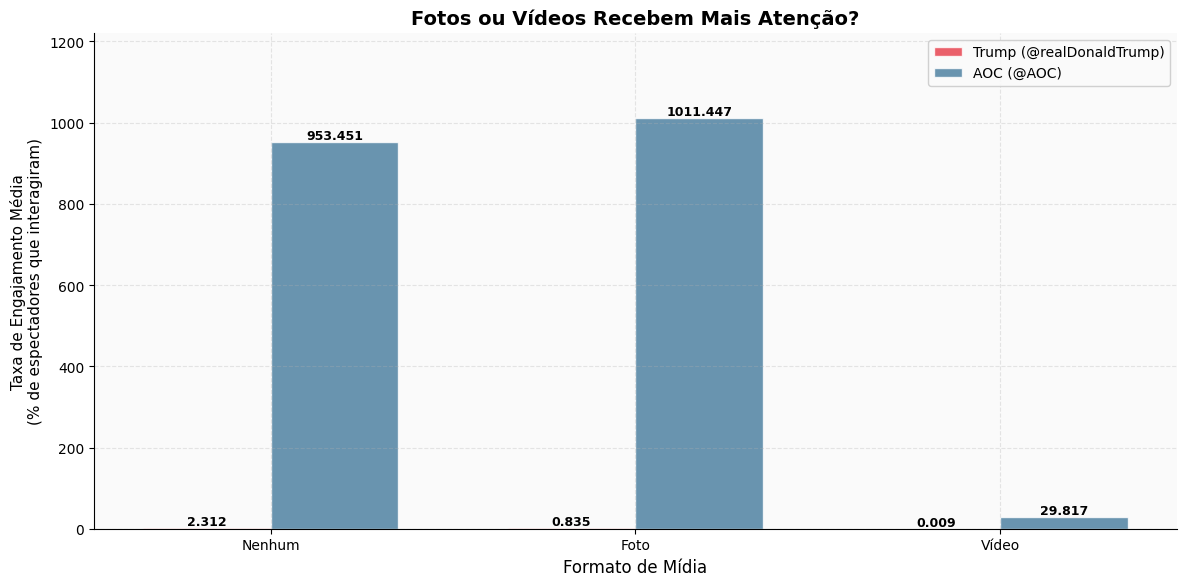


Número de tweets por formato de mídia:
media_type  none  photo  video
user                          
aoc           95      4      1
trump         41     25     34


In [10]:
# --- Fotos ou Vídeos Recebem Mais Atenção? ---

media_types = ['none', 'photo', 'video', 'mixed']
# Incluir apenas tipos de mídia que existem nos dados
available_media_types = [mt for mt in media_types if mt in df['media_type'].cat.categories
                         or mt in df['media_type'].unique()]

media_labels_map = {'none': 'Nenhum', 'photo': 'Foto', 'video': 'Vídeo', 'mixed': 'Misto'}

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

x = np.arange(len(available_media_types))
width = 0.35

for i, user in enumerate(['trump', 'aoc']):
    means = []
    for mt in available_media_types:
        subset = df[(df['user'] == user) & (df['media_type'] == mt)]
        means.append(subset['engagement_rate'].mean() if len(subset) > 0 else 0)
    
    offset = -width/2 + i * width
    bars = ax.bar(x + offset, means, width, label=get_user_label(user),
                  color=colors[user], alpha=0.8, edgecolor='white')
    
    # Adicionar rótulos de valor
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Formato de Mídia', fontsize=12)
ax.set_ylabel('Taxa de Engajamento Média\n(% de espectadores que interagiram)', fontsize=11)
ax.set_title('Fotos ou Vídeos Recebem Mais Atenção?', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([media_labels_map.get(mt, mt.title()) for mt in available_media_types])
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()

# Mostrar contagens de tweets por tipo de mídia
print("\nNúmero de tweets por formato de mídia:")
print(df.groupby(['user', 'media_type'], observed=True).size().unstack(fill_value=0))

### O que isso nos diz?

Este gráfico compara a taxa média de engajamento para tweets apenas com texto, fotos, vídeos e mídia mista para cada político. Quanto mais alta a barra, mais eficaz aquele formato é para fazer as pessoas interagirem.

Observe se o mesmo formato funciona melhor para ambos os políticos, ou se eles têm diferentes "fórmulas vencedoras". Também verifique a tabela abaixo do gráfico: se um formato tem apenas alguns tweets, a média pode não ser confiável (um único tweet viral poderia distorcer os resultados).

Isso tem implicações práticas: se a equipe de um político quer maximizar o engajamento, deveria prestar atenção em quais formatos performam melhor.

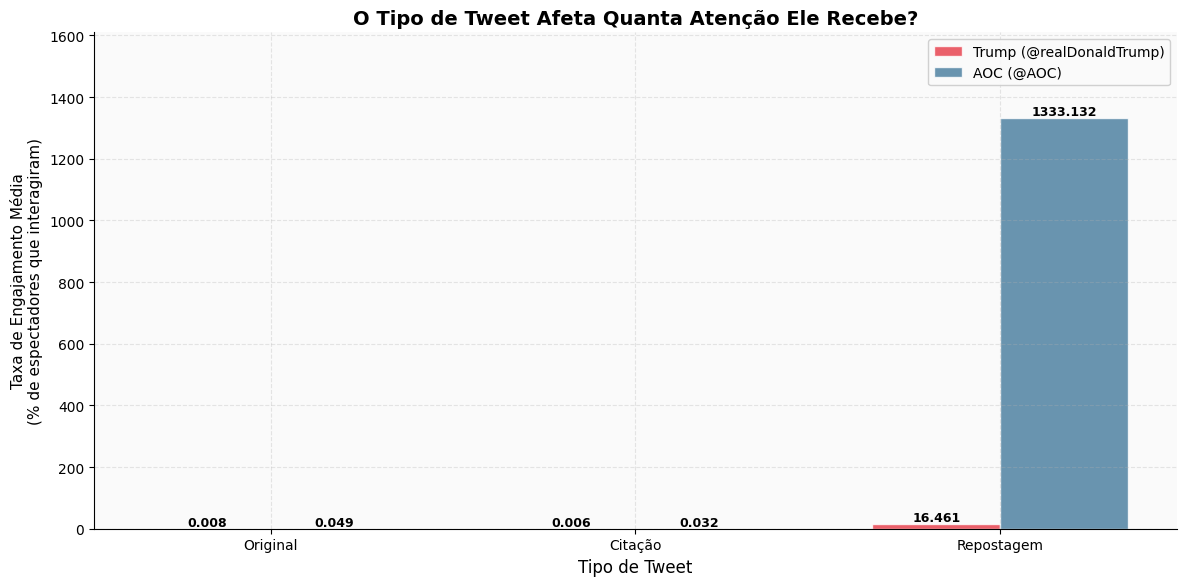


Número de tweets por tipo:
tweet_type  Citação  Original  Repostagem
user                                     
aoc              23         6          71
trump             3        90           7


In [11]:
# --- O Tipo de Tweet Faz Diferença? (Original vs Resposta vs Citação vs Repostagem) ---

def classify_tweet_type(row):
    if row['is_retweet']:
        return 'Repostagem'
    elif row['is_quote']:
        return 'Citação'
    elif row['is_reply']:
        return 'Resposta'
    else:
        return 'Original'

df['tweet_type'] = df.apply(classify_tweet_type, axis=1)
tweet_types = ['Original', 'Resposta', 'Citação', 'Repostagem']
# Filtrar para tipos que realmente existem
available_tweet_types = [tt for tt in tweet_types if tt in df['tweet_type'].unique()]

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

x = np.arange(len(available_tweet_types))
width = 0.35

for i, user in enumerate(['trump', 'aoc']):
    means = []
    for tt in available_tweet_types:
        subset = df[(df['user'] == user) & (df['tweet_type'] == tt)]
        means.append(subset['engagement_rate'].mean() if len(subset) > 0 else 0)
    
    offset = -width/2 + i * width
    bars = ax.bar(x + offset, means, width, label=get_user_label(user),
                  color=colors[user], alpha=0.8, edgecolor='white')
    
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Tipo de Tweet', fontsize=12)
ax.set_ylabel('Taxa de Engajamento Média\n(% de espectadores que interagiram)', fontsize=11)
ax.set_title('O Tipo de Tweet Afeta Quanta Atenção Ele Recebe?', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(available_tweet_types)
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()

# Mostrar contagens de tweets por tipo
print("\nNúmero de tweets por tipo:")
print(df.groupby(['user', 'tweet_type'], observed=True).size().unstack(fill_value=0))

### O que isso nos diz?

Este gráfico responde uma pergunta importante: tweets originais, respostas, citações ou repostagens geram mais engajamento? A resposta pode variar por político.

Tweets originais são conteúdo novo do político, então frequentemente refletem a mensagem central do político. Citações permitem que comentem o conteúdo de outra pessoa, o que pode ser uma maneira de comprar brigas, expressar solidariedade ou adicionar contexto. Respostas são conversacionais, e repostagens são simplesmente amplificação de outros.

Se tweets originais têm a maior taxa de engajamento, sugere que a audiência valoriza a própria voz do político acima de tudo. Se citações ou respostas se saem melhor, pode significar que a audiência gosta das interações do político com outros.

## 5. Quando É o Melhor Horário para Postar?

A hora do dia ou o dia da semana afetam quanto engajamento um tweet recebe? Este mapa de calor mostra a taxa média de engajamento para cada combinação de hora e dia.

Entender quando as audiências estão mais receptivas é crucial para a estratégia de comunicação política. Um tweet bem cronometrado pode alcançar as pessoas quando elas estão mais propensas a engajar, enquanto um mal cronometrado pode ser enterrado sob outro conteúdo.

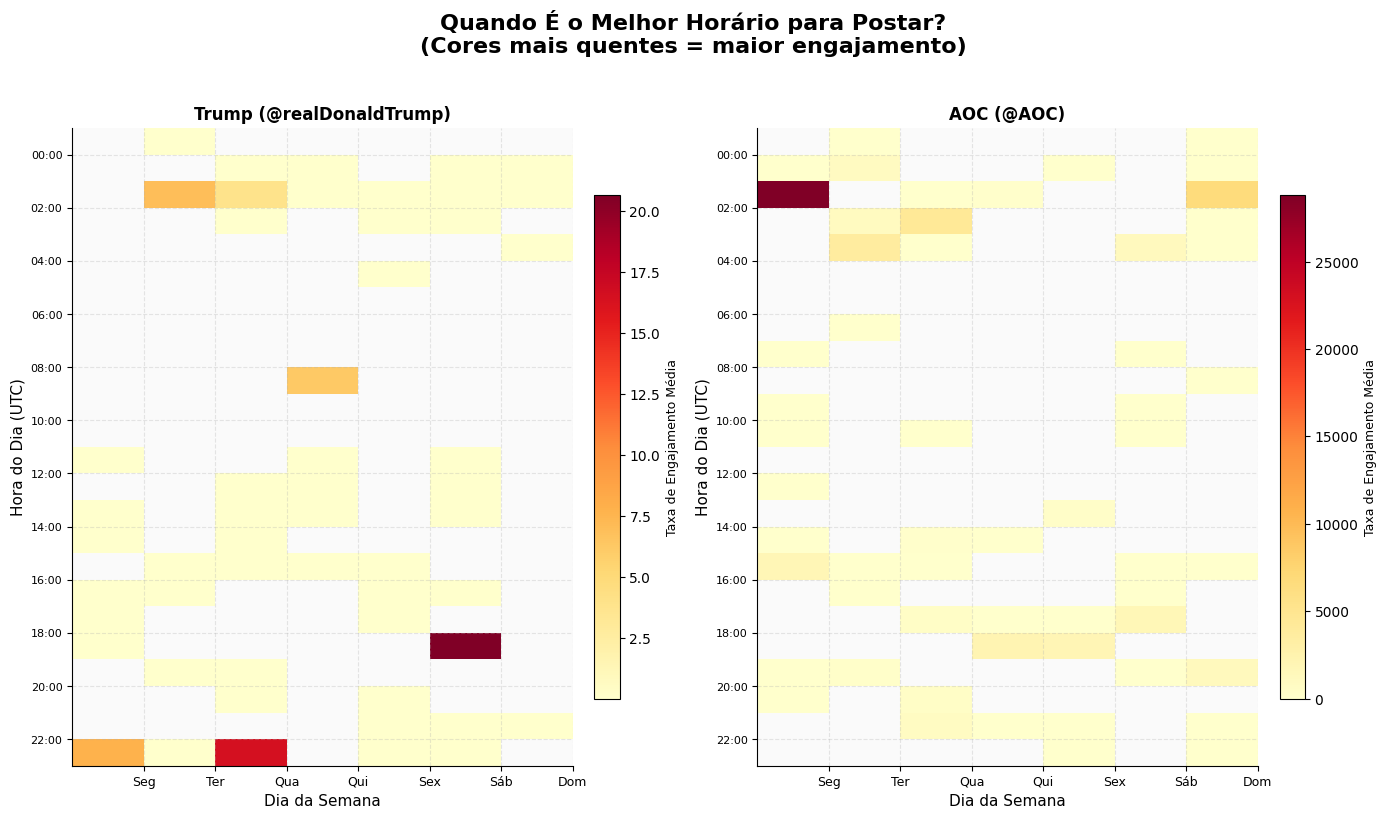

In [12]:
# --- Quando É o Melhor Horário para Postar? (Mapa de Calor de Engajamento) ---

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_df = df[df['user'] == user].copy()
    
    # Criar tabela: taxa média de engajamento por hora e dia
    day_map = {name: i for i, name in enumerate(day_names)}
    user_df['day_num'] = user_df['day_name'].map(day_map)
    
    pivot = user_df.pivot_table(
        values='engagement_rate',
        index='hour',
        columns='day_num',
        aggfunc='mean'
    )
    
    # Garantir que todas as horas e dias estejam representados
    all_hours = range(24)
    all_days = range(7)
    pivot = pivot.reindex(index=all_hours, columns=all_days)
    
    # Plotar mapa de calor (cores mais quentes = maior engajamento)
    im = ax.pcolormesh(pivot.columns.values - 0.5,
                       pivot.index.values - 0.5,
                       pivot.values,
                       cmap='YlOrRd', shading='auto')
    
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_abbr, fontsize=9)
    ax.set_yticks(range(0, 24, 2))
    ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], fontsize=8)
    ax.set_xlabel('Dia da Semana', fontsize=11)
    ax.set_ylabel('Hora do Dia (UTC)', fontsize=11)
    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=12)
    ax.invert_yaxis()
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Taxa de Engajamento Média', fontsize=9)

fig.suptitle('Quando É o Melhor Horário para Postar?\n(Cores mais quentes = maior engajamento)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### O que isso nos diz?

Estes mapas de calor mostram a taxa média de engajamento para cada combinação de hora e dia da semana. **Cores mais quentes (laranja/vermelho) significam maior engajamento**, enquanto **cores mais claras (amarelo/branco) significam menor engajamento**. Células vazias (brancas) significam que nenhum tweet foi postado naquele horário.

Procure "pontos quentes" -- horários específicos em que o engajamento atinge o pico. Eles coincidem com horários típicos de vigília nos EUA? Os padrões de fim de semana diferem dos de dias úteis? Se um político obtém maior engajamento em horários incomuns, pode significar que seus seguidores mais engajados estão em fusos horários diferentes ou têm horários não convencionais.

Note que como temos apenas 100 tweets por político, alguns intervalos de tempo podem ter poucos tweets (ou nenhum), então células individuais devem ser interpretadas com cautela. O padrão geral é mais importante do que qualquer célula individual.

## 6. Salvos: Quais Tweets as Pessoas Guardam para Depois?

**Salvos** são uma forma especial de engajamento. Diferente de uma rápida "curtida" (que é pública e frequentemente impulsiva), salvar um tweet é um **ato privado e deliberado**. As pessoas salvam tweets para os quais querem voltar -- porque o conteúdo é útil, importante ou vale a pena compartilhar depois.

Isso torna os salvos uma janela para um tipo diferente de valor. Um tweet com muitos salvos pode conter detalhes de políticas públicas, informações úteis ou argumentos que as pessoas querem referenciar em discussões futuras. Isso sinaliza que o conteúdo tem valor duradouro além do momento imediato.

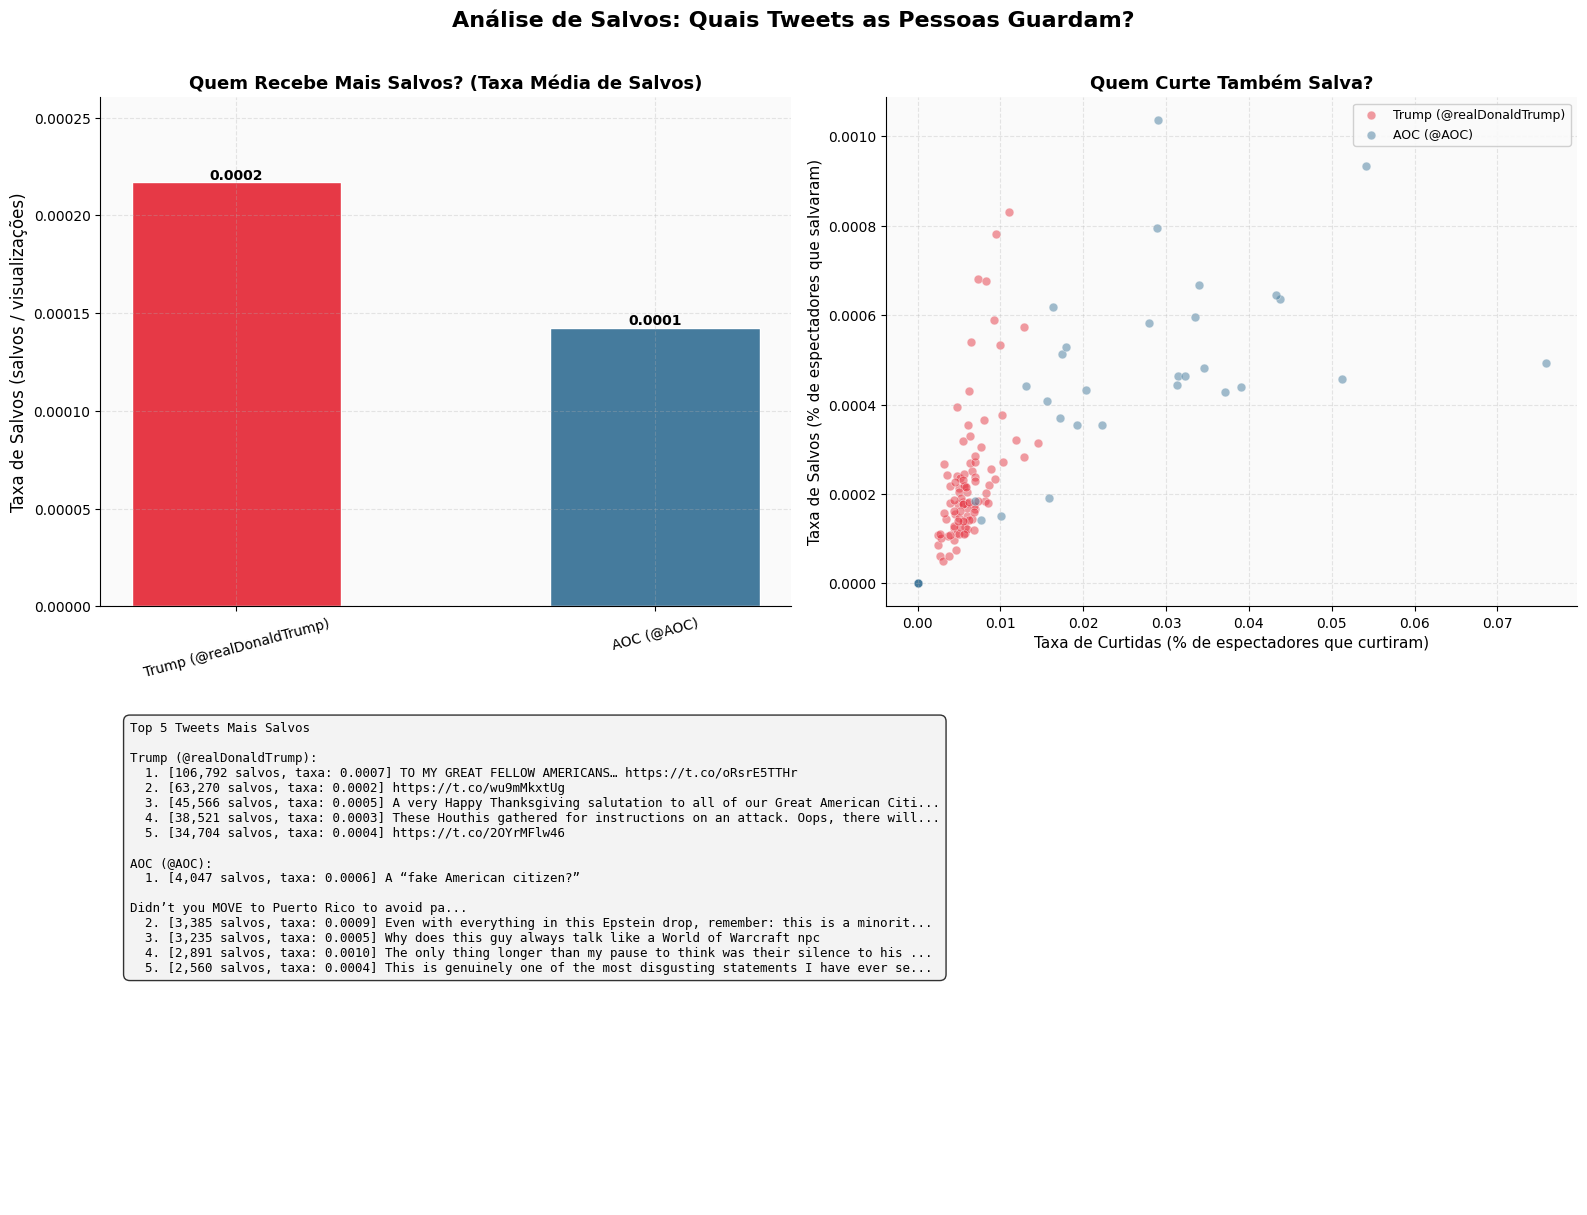

In [13]:
# --- Análise de Salvos ---

fig = plt.figure(figsize=(16, 12))

# --- Parte 1: Quem Recebe Mais Salvos? ---
ax1 = fig.add_subplot(2, 2, 1)
users = ['trump', 'aoc']
mean_save_rates = [df[df['user'] == u]['save_rate'].mean() for u in users]
user_labels = [get_user_label(u) for u in users]

bars = ax1.bar(user_labels, mean_save_rates,
               color=[colors[u] for u in users], width=0.5, edgecolor='white')

for bar, val in zip(bars, mean_save_rates):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Quem Recebe Mais Salvos? (Taxa Média de Salvos)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Taxa de Salvos (salvos / visualizações)')
ax1.set_ylim(0, max(mean_save_rates) * 1.2 if max(mean_save_rates) > 0 else 0.001)
ax1.tick_params(axis='x', rotation=15)

# --- Parte 2: Quem Curte Também Salva? ---
ax2 = fig.add_subplot(2, 2, 2)

for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]
    ax2.scatter(user_data['like_rate'], user_data['save_rate'],
               color=colors[user], alpha=0.5, s=40,
               label=get_user_label(user), edgecolors='white', linewidth=0.5)

ax2.set_xlabel('Taxa de Curtidas (% de espectadores que curtiram)', fontsize=11)
ax2.set_ylabel('Taxa de Salvos (% de espectadores que salvaram)', fontsize=11)
ax2.set_title('Quem Curte Também Salva?', fontweight='bold', fontsize=13)
ax2.legend(fontsize=9)

# --- Parte 3: Os Tweets Mais Salvos ---
ax3 = fig.add_subplot(2, 1, 2)
ax3.axis('off')

top_bookmarked_text = []
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user].nlargest(5, 'bookmark_count')
    label = get_user_label(user)
    top_bookmarked_text.append(f"\n{label}:")
    for rank, (_, row) in enumerate(user_df.iterrows(), 1):
        text_preview = row['text'][:70] + '...' if len(str(row['text'])) > 70 else row['text']
        bookmarks = int(row['bookmark_count'])
        saves = row['save_rate']
        top_bookmarked_text.append(
            f"  {rank}. [{bookmarks:,} salvos, taxa: {saves:.4f}] {text_preview}"
        )

full_text = "Top 5 Tweets Mais Salvos\n" + "\n".join(top_bookmarked_text)
ax3.text(0.02, 0.95, full_text, transform=ax3.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.8))

fig.suptitle('Análise de Salvos: Quais Tweets as Pessoas Guardam?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### O que isso nos diz?

Três coisas para notar:

1. **Taxa média de salvos** (canto superior esquerdo): Qual político tem conteúdo que as pessoas mais salvam? Uma taxa de salvos mais alta sugere que o conteúdo tem utilidade duradoura -- as pessoas querem voltar a ele.

2. **Curtidas vs. salvos** (canto superior direito): Cada ponto é um tweet. Se os pontos formam uma linha ascendente da esquerda para a direita, significa que tweets que recebem mais curtidas também tendem a receber mais salvos. Se os pontos estão dispersos, curtidas e salvos medem coisas diferentes.

3. **Tweets mais salvos** (parte inferior): Leia o texto real dos tweets mais salvos. Que tipo de conteúdo é? Detalhes de políticas? Declarações poderosas? Reações a notícias? O conteúdo que as pessoas escolhem salvar revela o que consideram digno de referência, não apenas entretenimento.

## 7. Principais Conclusões: O Que Aprendemos Sobre Engajamento

Após analisar como as audiências respondem aos tweets de Trump e AOC, aqui estão as principais descobertas:

**Quem recebe mais atenção total?**
- Trump, como ex-presidente com um enorme número de seguidores, gera números brutos significativamente mais altos em visualizações, curtidas e repostagens. Isso reflete a enorme escala de sua presença na plataforma e a intensidade da atenção pública ao redor de suas postagens.
- No entanto, os totais brutos sozinhos não contam a história completa. O tamanho da audiência importa: um político que alcança 50 milhões de pessoas por tweet naturalmente acumulará mais curtidas do que um que alcança 5 milhões, mesmo se ambos forem igualmente envolventes.

**Quem se conecta mais efetivamente com sua audiência?**
- A análise de taxa de engajamento revela a qualidade da conexão entre político e audiência, independente da contagem bruta de seguidores. Uma taxa de engajamento mais alta significa que uma proporção maior de espectadores responde ativamente ao conteúdo.
- Diferenças na taxa de engajamento apontam para diferenças em como a audiência de cada político se relaciona com eles: consumo passivo vs. participação ativa.

**O que faz um tweet viralizar?**
- Os tweets mais virais de cada político tendem a compartilhar certas características: abordam temas emocionalmente carregados, usam linguagem forte e falam às preocupações centrais de suas respectivas audiências.
- A viralidade não é aleatória -- reflete o alinhamento entre uma mensagem e os valores e emoções de sua audiência.

**O formato importa?**
- A relação entre formato de mídia (texto, foto, vídeo) e engajamento varia entre os dois políticos. O que funciona para uma audiência pode não funcionar para outra, sugerindo que estratégias ótimas de comunicação são específicas para cada audiência.
- O tipo de tweet (original vs. citação vs. resposta) também afeta o engajamento de forma diferente, refletindo o estilo de comunicação único de cada político e as expectativas de sua audiência.

**Quando devem postar?**
- Os mapas de calor de engajamento revelam que o momento importa, mas os horários ideais de postagem diferem entre os dois políticos. Isso provavelmente reflete as diferentes demografias e hábitos de suas respectivas audiências.
- Diferenças entre fim de semana e dias úteis também surgem, sugerindo que o ciclo de atenção política não para nos fins de semana nas redes sociais.

**E quanto aos salvos?**
- O comportamento de salvos revela uma dimensão de engajamento que curtidas e repostagens não capturam. As pessoas salvam conteúdo que consideram genuinamente útil ou importante, não apenas divertido ou provocativo.
- Os tipos de tweets que recebem salvos nos dizem sobre o valor informacional e de referência do conteúdo de cada político, além de seu impacto emocional imediato.

---

### Perspectiva Histórica

Essas métricas de engajamento representam algo genuinamente novo na história da comunicação política. Pela primeira vez, podemos medir -- em tempo real e em escala -- como as audiências recebem mensagens políticas. Cada curtida é um microendosso. Cada repostagem é um ato de amplificação. Cada resposta é uma peça de discurso público. Juntas, elas formam um rico arquivo de como os públicos democráticos se engajam com seus representantes na era digital.

### O Que Vem a Seguir

Nos próximos notebooks, iremos além de *quanta* atenção cada político recebe e examinaremos *o que* eles realmente dizem (análise de conteúdo e linguagem), *quem* interage com eles (análise de rede), e o que tudo isso significa para entender a comunicação política digital.

---

*Nota: Esta análise é baseada em uma amostra de 100 tweets por político. Embora isso forneça insights significativos sobre padrões recentes, representa um retrato e não uma história abrangente. Como com qualquer fonte histórica, a amostra deve ser interpretada com consciência de suas limitações.*